# Clasificación de Quejas Financieras con DistilBERT

**Integrantes:** Yuri Biardo | Andrea Aranda | Mariana Sambucetti

**Curso:** Técnicas de Inteligencia Artificial: Deep Learning — Febrero 2026

---

## ¿De qué se trata?

La idea del proyecto es tomar quejas de consumidores (textos que escriben las personas cuando tienen un problema con algún producto financiero) y entrenar un modelo para que las clasifique en 5 categorías:

1. `credit_card` - Tarjetas de crédito
2. `credit_reporting` - Reportes de crédito
3. `debt_collection` - Cobro de deudas
4. `mortgages_and_loans` - Hipotecas y préstamos
5. `retail_banking` - Banca minorista

Usamos **DistilBERT**, una versión compacta de BERT (Bidirectional Encoder Representations from Transformers), un modelo pre-entrenado de lenguaje (LLM) basado en la arquitectura **Transformer**. Los Transformers utilizan un mecanismo llamado **self-attention** que permite al modelo analizar todas las palabras de un texto simultáneamente y entender las relaciones entre ellas. Luego vamos a ajustarlo (fine-tune) a nuestro problema específico.

### ¿Qué es fine-tuning?
Básicamente es agarrar un modelo que ya sabe leer y entender texto (porque fue entrenado con millones de textos) y enseñarle una tarea puntual. Es mucho mejor que arrancar de cero.

---
## Instalar librerías

Lo primero es instalar lo que vamos a necesitar:
- **transformers**: la librería de Hugging Face, que trae modelos pre-entrenados como DistilBERT
- **datasets**: para manejar los datos
- **accelerate**: para que el entrenamiento use la GPU
- **scikit-learn**: para las métricas (accuracy, F1, etc.)

In [ ]:
# Instalamos lo que necesitamos.
# -q para que no tire tanta info
!pip install -q transformers datasets accelerate scikit-learn

---
## Importar librerías

Acá importamos todo lo que vamos a usar.

In [ ]:
# Librerías generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch                       # Hugging Face lo usa por debajo

# Hugging Face
from transformers import (
    AutoTokenizer,                          # convierte texto en números
    AutoModelForSequenceClassification,     # modelo para clasificación
    TrainingArguments,                      # Configuración del entrenamiento (epochs, learning rate, etc.)
    Trainer,                                # maneja todo el entrenamiento
    DataCollatorWithPadding                 # iguala el largo de las secuencias
)
from datasets import Dataset               # formato de datos de HF

# Métricas
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split

# Config
import warnings
warnings.filterwarnings('ignore')  # sacamos los warnings molestos

In [ ]:
# Fijamos una seed para que los resultados sean reproducibles
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

---
## Cargar el dataset

Descargamos el dataset directo desde Kaggle usando la API. Hay que subir el archivo `kaggle.json` con las credenciales.

In [ ]:
# Subimos el archivo kaggle.json (credenciales de la API de Kaggle)
from google.colab import files

print("Seleccioná tu archivo kaggle.json:")
uploaded = files.upload()

# Configuramos las credenciales de Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Descargamos el dataset
!pip install -q kaggle
!kaggle datasets download -d shashwatwork/consume-complaints-dataset-fo-nlp

# Descomprimimos el archivo descargado
!unzip -q -o consume-complaints-dataset-fo-nlp.zip

# Leemos el CSV
import glob
archivo_csv = glob.glob("*.csv")[0]
df = pd.read_csv(archivo_csv)

Seleccioná tu archivo kaggle.json:


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/shashwatwork/consume-complaints-dataset-fo-nlp
License(s): copyright-authors
consume-complaints-dataset-fo-nlp.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Veamos las primeras filas para entender la estructura
print(f"El dataset tiene {len(df)} filas y {len(df.columns)} columnas")
print(f"\n Columnas: {list(df.columns)}")
print("\n Primeras 5 filas:")
df.head()

El dataset tiene 162421 filas y 3 columnas

 Columnas: ['Unnamed: 0', 'product', 'narrative']

 Primeras 5 filas:


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


---
## Exploración y limpieza de datos

Antes de meternos con el modelo, miremos los datos para entender qué tenemos.

In [ ]:
# Renombramos las columnas para que sean más claras
# (ajustar si los nombres son diferentes en tu archivo)
print("Nombres actuales de las columnas:")
print(df.columns.tolist())
print("\nTipos de datos:")
print(df.dtypes)

Nombres actuales de las columnas:
['Unnamed: 0', 'product', 'narrative']

Tipos de datos:
Unnamed: 0     int64
product       object
narrative     object
dtype: object


In [ ]:
# Veamos cuántas categorías hay y cuántas quejas tiene cada una
print("Distribución de categorías de producto:\n")
conteo = df['product'].value_counts()
porcentaje = df['product'].value_counts(normalize=True) * 100

# Creamos una tabla con cantidad y porcentaje lado a lado
distribucion = pd.DataFrame({
    'Cantidad': conteo,
    'Porcentaje (%)': porcentaje.round(2)
})
print(distribucion)
print(f"\nTotal de categorías: {df['product'].nunique()}")
print(f"Total de registros: {len(df)}")

Distribución de categorías de producto:

                     Cantidad  Porcentaje (%)
product                                      
credit_reporting        91179           56.14
debt_collection         23150           14.25
mortgages_and_loans     18990           11.69
credit_card             15566            9.58
retail_banking          13536            8.33

Total de categorías: 5
Total de registros: 162421


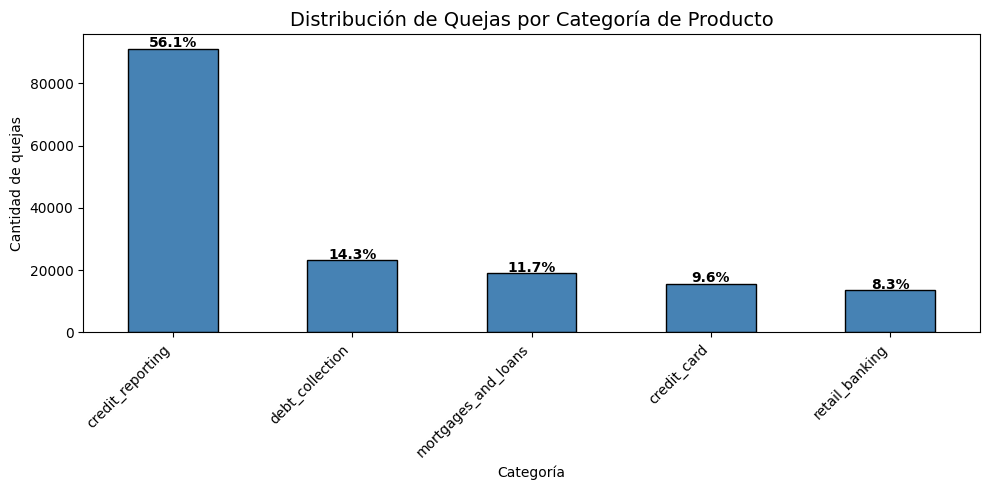

In [ ]:
# Gráfico de barras para visualizar la distribución de clases
# Esto nos ayuda a ver si hay desbalance (algunas categorías con muchos más datos que otras)

plt.figure(figsize=(10, 5))
ax = conteo.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribución de Quejas por Categoría de Producto', fontsize=14)
plt.xlabel('Categoría')
plt.ylabel('Cantidad de quejas')
plt.xticks(rotation=45, ha='right')

# Agregamos el porcentaje arriba de cada barra
for i, (valor, pct) in enumerate(zip(conteo, porcentaje)):
    ax.text(i, valor + 500, f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

**Desbalance:**
`credit_reporting` tiene el 56% de los datos y `retail_banking` apenas el 8%. Si no hacemos nada, el modelo se va a viciar y va a tender a predecir siempre `credit_reporting`. Más adelante lo corregimos con pesos de clase.

In [ ]:
# Veamos cuántos valores vacíos (NaN) hay en cada columna
# Los NaN son datos faltantes que no nos sirven para entrenar el modelo
print("Valores vacíos por columna:\n")
vacios = df[['narrative', 'product']].isnull().sum()
total = len(df)
for col in ['narrative', 'product']:
    cant = vacios[col]
    pct = cant / total * 100
    print(f"   {col}: {cant} vacíos ({pct:.2f}%)")

print(f"\nTotal de filas: {total}")

Valores vacíos por columna:

   narrative: 10 vacíos (0.01%)
   product: 0 vacíos (0.00%)

Total de filas: 162421


In [ ]:
# Eliminamos filas que tengan valores vacíos (NaN) en las columnas que nos interesan ya que representan menos del 10%.
# Si el texto está vacío, no podemos clasificar nada
filas_antes = len(df)
df = df[['narrative', 'product']].dropna()
filas_despues = len(df)

print(f"Filas eliminadas por valores vacíos: {filas_antes - filas_despues}")
print(f"Filas restantes: {filas_despues}")

Filas eliminadas por valores vacíos: 10
Filas restantes: 162411


In [ ]:
#Verificar que haya eliminado los vacios
vacios = df[['narrative', 'product']].isnull().sum()
total = len(df)
for col in ['narrative', 'product']:
    cant = vacios[col]
    pct = cant / total * 100
    print(f"   {col}: {cant} vacíos ({pct:.2f}%)")

print(f"\nTotal de filas: {total}")

   narrative: 0 vacíos (0.00%)
   product: 0 vacíos (0.00%)

Total de filas: 162411


In [ ]:
# Veamos un ejemplo de queja para cada categoría
print("Ejemplo de queja por categoría:\n")
for categoria in df['product'].unique():
    ejemplo = df[df['product'] == categoria]['narrative'].iloc[0]
    # Mostramos solo los primeros 200 caracteres para no llenar la pantalla
    print(f"{categoria}:")
    print(f" {ejemplo[:200]}...\n")

Ejemplo de queja por categoría:

credit_card:
 purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order ...

retail_banking:
 forwarded message cc sent friday pdt subject final legal payment well fargo well fargo clearly wrong need look actually opened account see court hearing several different government agency reporting w...

credit_reporting:
 payment history missing credit report specialized loan servicing sl made mistake put account forbearance without authorization knowledge matter fact automatic payment setup month monthly mortgage paid...

mortgages_and_loans:
 beginning mortgage held mb financial mb mortgage portfolio purchased bank first quarter mb financial customer began fall behind mortgage payment due unemployment divorce house went foreclosure later s...

debt_collection:
 collection agency system inc mn phone sent letter regardi

---
## Preparar las etiquetas

El modelo trabaja con números, no con texto. Así que tenemos que pasar las categorías ("credit_card", "debt_collection", etc.) a números (0, 1, 2, 3, 4).

In [ ]:
# Obtenemos la lista de categorías únicas y las ordenamos
categorias = sorted(df['product'].unique())
num_categorias = len(categorias)

# Creamos diccionarios para convertir entre texto y número
# label2id: "credit_card" - 0, "credit_reporting" - 1, etc.
# id2label: 0 - "credit_card", 1 - "credit_reporting", etc.
label2id = {label: idx for idx, label in enumerate(categorias)}
id2label = {idx: label for label, idx in label2id.items()}

print(f"Número de categorías totales: {num_categorias}\n")
print("Mapeo categoría - número:")
for label, idx in label2id.items():
    print(f"   {label} - {idx}")

Número de categorías totales: 5

Mapeo categoría - número:
   credit_card - 0
   credit_reporting - 1
   debt_collection - 2
   mortgages_and_loans - 3
   retail_banking - 4


In [ ]:
# Agregamos una columna numérica con la etiqueta
# Usamos el diccionario label2id para convertir cada categoría a su número
df['label'] = df['product'].map(label2id)

# Verificamos que se creó bien
print("Columna 'label' creada:")
print(df[['product', 'label']].drop_duplicates().sort_values('label').to_string(index=False))

Columna 'label' creada:
            product  label
        credit_card      0
   credit_reporting      1
    debt_collection      2
mortgages_and_loans      3
     retail_banking      4


---
## Dividir los datos en Train / Validation / Test

Separamos los datos en 3 partes:

- **Train (80%)**: con estos el modelo aprende
- **Validation (10%)**: es como un parcial, al final de cada epoch chequeamos si va mejorando o se está sobreajustando
- **Test (10%)**: el examen final, datos que el modelo nunca vio ni de forma directa ni indirecta

Usamos `stratify` para que la proporción de cada categoría se mantenga igual en los 3 conjuntos. Si credit_reporting es el 56% del total, también va a ser el 56% en cada subset. Sino podría pasar que alguno quede con pocas quejas de alguna categoría.

In [ ]:
# Primera división: separamos el test (10%)
# stratify=df['label'] asegura que la proporción de categorías se mantenga
df_train_val, df_test = train_test_split(
    df, test_size=0.10, random_state=42, stratify=df['label']
)

# Segunda división: del 90% restante, separamos validación
# Usamos 0.111 porque 11.1% del 90% = 10% del total
df_train, df_val = train_test_split(
    df_train_val, test_size=0.111, random_state=42, stratify=df_train_val['label']
)

print(f"Tamaño de cada conjunto:")
print(f"   Train:      {len(df_train)} ({len(df_train)/len(df)*100:.1f}%)")
print(f"   Validation: {len(df_val)} ({len(df_val)/len(df)*100:.1f}%)")
print(f"   Test:       {len(df_test)} ({len(df_test)/len(df)*100:.1f}%)")
print(f"   Total:      {len(df_train) + len(df_val) + len(df_test)}")

Tamaño de cada conjunto:
   Train:      129944 (80.0%)
   Validation: 16225 (10.0%)
   Test:       16242 (10.0%)
   Total:      162411


---
## Tokenización

El modelo no puede leer texto así como está. Necesitamos pasarlo a números (tokens).

Lo que hace el tokenizador de DistilBERT:
1. Parte el texto en sub-palabras
2. A cada sub-palabra le asigna un número de su vocabulario
3. Agrega tokens especiales: `[CLS]` (classification) al inicio y `[SEP]` (separator) al final

Por ejemplo: "I have a credit card problem" se convierte en `[CLS] i have a credit card problem [SEP]` y eso a su vez en `[101, 1045, 2031, 1037, 4923, 4003, 3291, 102]`

In [ ]:
# Nombre del modelo pre-entrenado que vamos a usar
# "distilbert-base-uncased" significa:
#   - distilbert: versión compacta y rápida de BERT
#   - base: tamaño base (66 millones de parámetros)
#   - uncased: no distingue mayúsculas de minúsculas
NOMBRE_MODELO = "distilbert-base-uncased"

# Cargamos el tokenizador correspondiente a este modelo
tokenizer = AutoTokenizer.from_pretrained(NOMBRE_MODELO)

print(f"Tokenizador cargado: {NOMBRE_MODELO}")
print(f"Tamaño del vocabulario: {tokenizer.vocab_size} tokens")

Tokenizador cargado: distilbert-base-uncased
Tamaño del vocabulario: 30522 tokens


In [ ]:
# Convertimos nuestros DataFrames de pandas a Datasets de Hugging Face
# Esto es necesario porque el Trainer de Hugging Face espera este formato

# Nos quedamos solo con las columnas que necesitamos: texto y etiqueta numérica
train_dataset = Dataset.from_pandas(df_train[['narrative', 'label']].reset_index(drop=True))
val_dataset = Dataset.from_pandas(df_val[['narrative', 'label']].reset_index(drop=True))
test_dataset = Dataset.from_pandas(df_test[['narrative', 'label']].reset_index(drop=True))

print(f"Datasets creados:")
print(f"  Train: {train_dataset}")
print(f"  Val:   {val_dataset}")
print(f"  Test:  {test_dataset}")

Datasets creados:
  Train: Dataset({
    features: ['narrative', 'label'],
    num_rows: 129944
})
  Val:   Dataset({
    features: ['narrative', 'label'],
    num_rows: 16225
})
  Test:  Dataset({
    features: ['narrative', 'label'],
    num_rows: 16242
})


In [ ]:
# Veamos cuántos tokens tiene cada queja para elegir bien el MAX_LENGTH
largos = df['narrative'].apply(lambda x: len(tokenizer(x)['input_ids']))

print(f"Largo de las quejas (en tokens):\n")
print(f"   Mínimo:    {largos.min()}")
print(f"   Promedio:  {largos.mean():.0f}")
print(f"   Mediana:   {largos.median():.0f}")
print(f"   Máximo:    {largos.max()}")
print(f"\nPorcentaje de quejas que caben en cada largo:")
for largo in [128, 256, 384, 512]:
    pct = (largos <= largo).mean() * 100
    print(f"   {largo} tokens: {pct:.1f}%")

Token indices sequence length is longer than the specified maximum sequence length for this model (569 > 512). Running this sequence through the model will result in indexing errors


Largo de las quejas (en tokens):

   Mínimo:    3
   Promedio:  91
   Mediana:   57
   Máximo:    3312

Porcentaje de quejas que caben en cada largo:
   128 tokens: 81.2%
   256 tokens: 94.6%
   384 tokens: 97.5%
   512 tokens: 98.7%


In [ ]:
# Usamos 256 tokens como largo máximo (cubre el 94.6% de las quejas)
# El promedio es 91 tokens y la mediana 57, así que 256 es más que suficiente para la mayoría
# Las quejas más largas se cortan, pero son solo el 5.4% de los datos
MAX_LENGTH = 256

def tokenize_function(examples):
    """Convierte los textos en tokens numéricos que el modelo puede procesar."""
    return tokenizer(
        examples['narrative'],
        truncation=True,       # Corta textos que superen max_length
        max_length=MAX_LENGTH,
        padding=False          # No agregamos padding acá, lo hace el DataCollator después
    )

# Aplicamos la tokenización a los 3 conjuntos
# batched=True hace que procese muchos textos a la vez (más rápido)
print("Tokenizando los datos (esto puede tardar unos minutos)...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("Tokenización completada!")
print(f"\nColumnas del dataset de entrenamiento: {train_dataset.column_names}")

Tokenizando los datos (esto puede tardar unos minutos)...


Map:   0%|          | 0/129944 [00:00<?, ? examples/s]

Map:   0%|          | 0/16225 [00:00<?, ? examples/s]

Map:   0%|          | 0/16242 [00:00<?, ? examples/s]

Tokenización completada!

Columnas del dataset de entrenamiento: ['narrative', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
# Eliminamos la columna de texto original porque el modelo solo necesita los tokens
train_dataset = train_dataset.remove_columns(['narrative'])
val_dataset = val_dataset.remove_columns(['narrative'])
test_dataset = test_dataset.remove_columns(['narrative'])

# Definimos el formato como PyTorch tensors
train_dataset.set_format('torch')
val_dataset.set_format('torch')
test_dataset.set_format('torch')

print("Datasets listos para el entrenamiento")
print(f"Columnas finales: {train_dataset.column_names}")

Datasets listos para el entrenamiento
Columnas finales: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Cargar el modelo pre-entrenado

Cargamos DistilBERT y le ponemos una capa de clasificación con 5 salidas (una por categoría).

Es como agarrar a alguien que ya sabe leer muy bien y enseñarle específicamente a clasificar quejas.

In [ ]:
# Cargamos el modelo con una capa de clasificación
# num_labels: cantidad de categorías a predecir (5 en nuestro caso)
# id2label y label2id: para que el modelo sepa qué significa cada número
model = AutoModelForSequenceClassification.from_pretrained(
    NOMBRE_MODELO,
    num_labels=num_categorias,
    id2label=id2label,
    label2id=label2id
)

# Mostramos información del modelo
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Modelo cargado: {NOMBRE_MODELO}")
print(f"Parámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")
print(f"Categorías: {num_categorias}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo cargado: distilbert-base-uncased
Parámetros totales: 66,957,317
Parámetros entrenables: 66,957,317
Categorías: 5


---
## Configurar el entrenamiento

Acá definimos los hiperparámetros, que son los "controles" de cómo aprende el modelo:

- **epochs**: cuántas vueltas le da a todos los datos. Más vueltas = aprende más, pero también puede sobreajustar
- **batch_size**: cuántos ejemplos procesa de una. Más grande = más rápido pero gasta más memoria
- **learning_rate**: el tamaño de los "pasos" que da al aprender. Si es muy grande se desestabiliza, si es muy chico tarda mucho

In [ ]:
# Definimos la función para calcular métricas durante el entrenamiento
# Esto nos permite ver cómo va mejorando el modelo en cada epoch

def compute_metrics(eval_pred):
    """
    Calcula accuracy y F1-score a partir de las predicciones del modelo.
    eval_pred contiene: (logits, labels)
    - logits: las predicciones "crudas" del modelo (un número por cada categoría)
    - labels: las etiquetas reales
    """
    logits, labels = eval_pred
    # Tomamos la categoría con el valor más alto como predicción
    # (argmax devuelve el índice del valor máximo)
    predictions = np.argmax(logits, axis=-1)

    # Calculamos accuracy (porcentaje de aciertos)
    acc = accuracy_score(labels, predictions)

    return {"accuracy": acc}

print("Función de métricas definida")

Función de métricas definida


In [ ]:
# Configuración del entrenamiento
training_args = TrainingArguments(
    output_dir="./resultados",                # Carpeta donde se guardan los checkpoints
    num_train_epochs=3,                       # Número de epochs, las vueltas completas por los datos
    per_device_train_batch_size=16,           # Ejemplos por batch en entrenamiento
    per_device_eval_batch_size=32,            # Ejemplos por batch en evaluación
    learning_rate=2e-5,                       # Tasa de aprendizaje
    weight_decay=0.01,                        # Regularización para evitar sobreajuste
    eval_strategy="epoch",                    # Evaluar al final de cada epoch
    save_strategy="epoch",                    # Guardar el modelo al final de cada epoch
    load_best_model_at_end=True,              # Al terminar, cargar el mejor modelo
    metric_for_best_model="accuracy",         # Criterio para elegir el "mejor" modelo
    logging_steps=100,                        # Cada cuántos pasos mostrar el progreso
    fp16=True,                                # Usa precisión mixta (más rápido en GPU)
    report_to="none",                         # No reportar a servicios externos
)

# El DataCollator se encarga de agregar padding dinámico
# Esto significa que solo rellena hasta el largo del texto más largo del batch actual
# (más eficiente que rellenar todo a 256 tokens)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Configuración de entrenamiento definida")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")

Configuración de entrenamiento definida
  Epochs: 3
  Batch size: 16
  Learning rate: 2e-05


In [ ]:
# Creamos el Trainer, que se encarga de todo el proceso de entrenamiento
trainer = Trainer(
    model=model,                    # El modelo a entrenar
    args=training_args,             # La configuración definida arriba
    train_dataset=train_dataset,    # Datos de entrenamiento
    eval_dataset=val_dataset,       # Datos de validación
    processing_class=tokenizer,     # El tokenizador
    data_collator=data_collator,    # El collator para el padding
    compute_metrics=compute_metrics # La función que calcula las métricas
)

---
## Entrenar el modelo

Ahora sí, a entrenar. Durante el proceso van a ver:
- **loss**: debería ir bajando (cuanto más bajo, mejor está aprendiendo)
- **accuracy**: debería ir subiendo

In [ ]:
# Entrenamos
print("Iniciando entrenamiento...\n")
train_result = trainer.train()

print("\nEntrenamiento completado!")
print(f"Tiempo total: {train_result.metrics['train_runtime']:.0f} segundos")
print(f"Loss final de entrenamiento: {train_result.metrics['train_loss']:.4f}")

Iniciando entrenamiento...



Epoch,Training Loss,Validation Loss,Accuracy
1,0.323104,0.315107,0.890169
2,0.242657,0.313256,0.896456
3,0.198593,0.326447,0.900586


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Entrenamiento completado!
Tiempo total: 2517 segundos
Loss final de entrenamiento: 0.3056


---
## Evaluar en el conjunto de test

Probamos el modelo con datos que nunca vio durante el entrenamiento, así sabemos realmente qué tan bien anda.

In [ ]:
# Hacemos predicciones sobre el conjunto de test
print("Evaluando en el conjunto de test...")
predictions = trainer.predict(test_dataset)

# Extraemos las predicciones y las etiquetas reales
# predictions.predictions son los logits (valores crudos)
# Tomamos el argmax para obtener la clase predicha
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Accuracy general
acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy en test: {acc:.4f} ({acc*100:.2f}%)")

Evaluando en el conjunto de test...



Accuracy en test: 0.8989 (89.89%)


In [ ]:
# Reporte de clasificación detallado
# Muestra precision, recall y F1-score para CADA categoría
#
# - Precision: De todas las quejas que el modelo dijo que eran "credit_card",
#              ¿qué porcentaje realmente lo era?
# - Recall: De todas las quejas que REALMENTE eran "credit_card",
#           ¿qué porcentaje el modelo identificó correctamente?
# - F1-score: Promedio armónico entre precision y recall (balance entre ambos)

print("Reporte de Clasificación Detallado:\n")
nombres_categorias = [id2label[i] for i in range(num_categorias)]
report = classification_report(y_true, y_pred, target_names=nombres_categorias)
print(report)

Reporte de Clasificación Detallado:

                     precision    recall  f1-score   support

        credit_card       0.83      0.82      0.82      1557
   credit_reporting       0.93      0.95      0.94      9118
    debt_collection       0.85      0.80      0.82      2315
mortgages_and_loans       0.88      0.83      0.85      1899
     retail_banking       0.89      0.90      0.89      1353

           accuracy                           0.90     16242
          macro avg       0.87      0.86      0.87     16242
       weighted avg       0.90      0.90      0.90     16242



## Sobre el reporte de clasificación

El modelo nos dio un accuracy del 90%, que está bastante bien para 5 categorías con tanto desbalance.

Mirando por categoría:
- **credit_reporting** (F1: 0.94) es la que mejor clasifica, tiene sentido porque es la que tiene más datos.
- **retail_banking** (F1: 0.89) anduvo muy bien considerando que tiene apenas el 8% de los datos. Los pesos de clase ayudaron bastante acá.
- **mortgages_and_loans** (F1: 0.85) bien.
- **credit_card y debt_collection** (F1: 0.82) son las que más le cuesta. Probablemente porque el lenguaje de esas quejas se parece bastante entre sí.

La diferencia entre macro avg (0.87) y weighted avg (0.90) nos dice que las categorías con más datos se clasifican un poco mejor, pero el desbalance no pegó tanto gracias a los pesos.

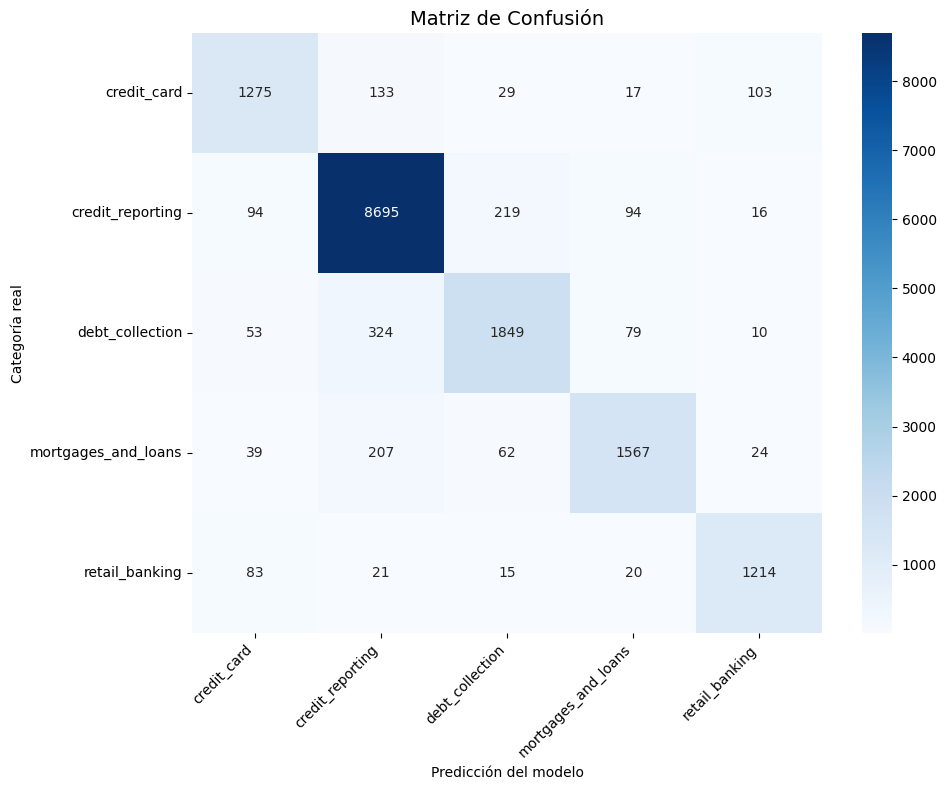

In [ ]:
# Matriz de confusión
# Muestra en una tabla cuántas quejas clasificó bien y cuántas confundió
# - Las filas son las categorías REALES
# - Las columnas son lo que el modelo PREDIJO
# - La diagonal (de arriba-izquierda a abajo-derecha) son los aciertos
# - Los valores fuera de la diagonal son los errores

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,           # Muestra los números dentro de cada celda
    fmt='d',              # Formato entero (sin decimales)
    cmap='Blues',          # Paleta de colores azul
    xticklabels=nombres_categorias,
    yticklabels=nombres_categorias
)
plt.title('Matriz de Confusión', fontsize=14)
plt.xlabel('Predicción del modelo')
plt.ylabel('Categoría real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

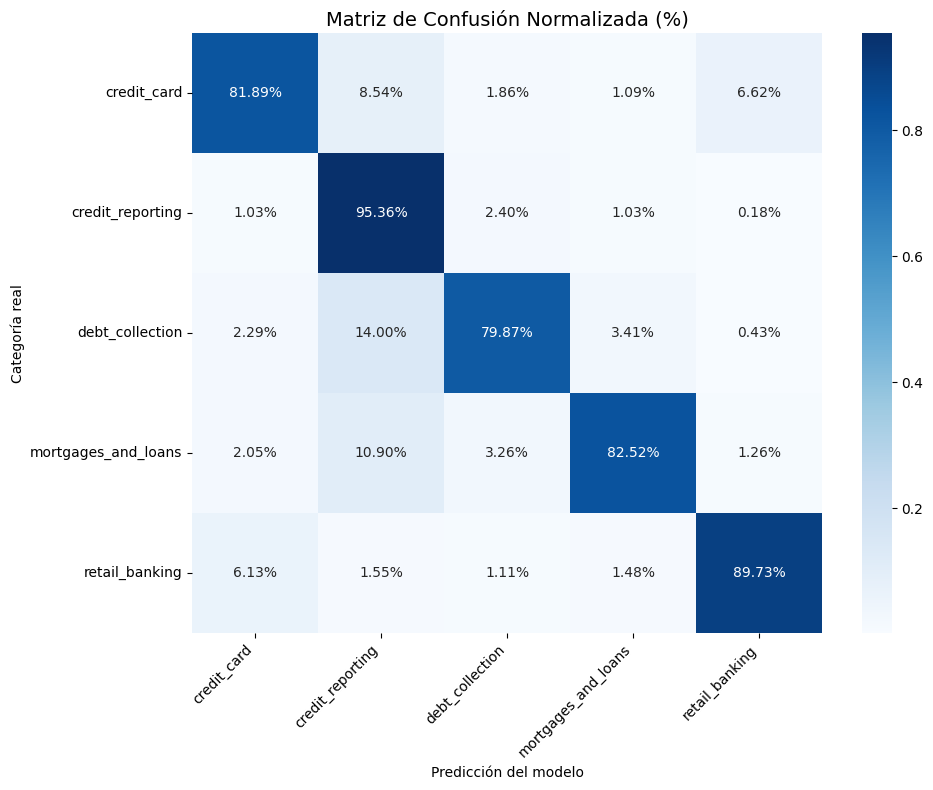

In [ ]:
# Matriz de confusión en porcentajes
# Más fácil de interpretar cuando las categorías tienen cantidades diferentes

cm_normalized = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2%',            # Formato porcentaje con 2 decimales
    cmap='Blues',
    xticklabels=nombres_categorias,
    yticklabels=nombres_categorias
)
plt.title('Matriz de Confusión Normalizada (%)', fontsize=14)
plt.xlabel('Predicción del modelo')
plt.ylabel('Categoría real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Sobre las matrices de confusión

Las dos matrices muestran lo mismo pero de distinta forma: una con números y otra con porcentajes. La de porcentajes es más práctica porque podemos comparar categorías que tienen cantidades muy distintas.

- **credit_reporting** se clasifica bien el 95.37% de las veces.
- **retail_banking** llega al 89.73% aunque tiene pocos datos. Los pesos de clase hicieron su trabajo.
- **credit_card, y mortgages_and_loans** andan por el 80%.
- **debt_collection** con 79.87%

Las confusiones más comunes:
- **debt_collection se confunde con credit_reporting** (14.17%). Tiene sentido porque las dos hablan de deudas y reportes.
- **mortgages_and_loans también se confunde con credit_reporting** (12.06%). Parecido, comparten vocabulario.
- **credit_card se confunde con retail_banking** (7.39%). Las dos son servicios bancarios al fin y al cabo.


---
## Probar con textos nuevos

Vamos a inventar algunas quejas para ver si el modelo las clasifica bien.

In [ ]:
def clasificar_queja(texto):
    """
    Toma un texto de queja y devuelve la categoría predicha por el modelo.
    """
    # Tokenizamos el texto
    inputs = tokenizer(texto, truncation=True, max_length=MAX_LENGTH, return_tensors="pt")

    # Movemos los datos a la GPU si está disponible
    device = model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Hacemos la predicción (sin calcular gradientes porque no estamos entrenando)
    model.eval()  # Ponemos el modelo en modo evaluación
    with torch.no_grad():
        outputs = model(**inputs)

    # Convertimos los logits a probabilidades con softmax
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(probabilities, dim=-1).item()
    confidence = probabilities[0][predicted_class].item()

    return id2label[predicted_class], confidence


# Probamos con algunos ejemplos
ejemplos = [
    "I was charged twice on my credit card for the same purchase and the bank refuses to refund me.", #credit_card
    "There is an error on my credit report showing a debt I already paid off years ago.", #credit_reporting
    "The debt collector keeps calling me at work even after I told them to stop.", #debt_collection
    "My mortgage payment increased without any notice from the lender.", #mortgages_and_loans
    "I cannot access my checking account online and the bank is not helping." #retail_banking
 ]

print("Predicciones del modelo:\n")
for texto in ejemplos:
    categoria, confianza = clasificar_queja(texto)
    print(f"Queja: {texto[:80]}...")
    print(f"Categoría: {categoria} (confianza: {confianza*100:.1f}%)\n")

Predicciones del modelo:

Queja: I was charged twice on my credit card for the same purchase and the bank refuses...
Categoría: credit_card (confianza: 92.1%)

Queja: There is an error on my credit report showing a debt I already paid off years ag...
Categoría: credit_reporting (confianza: 97.1%)

Queja: The debt collector keeps calling me at work even after I told them to stop....
Categoría: debt_collection (confianza: 99.1%)

Queja: My mortgage payment increased without any notice from the lender....
Categoría: mortgages_and_loans (confianza: 96.4%)

Queja: I cannot access my checking account online and the bank is not helping....
Categoría: retail_banking (confianza: 61.3%)



---
## Ver cómo fue el entrenamiento

Graficamos el loss y el accuracy para ver cómo evolucionó el aprendizaje.

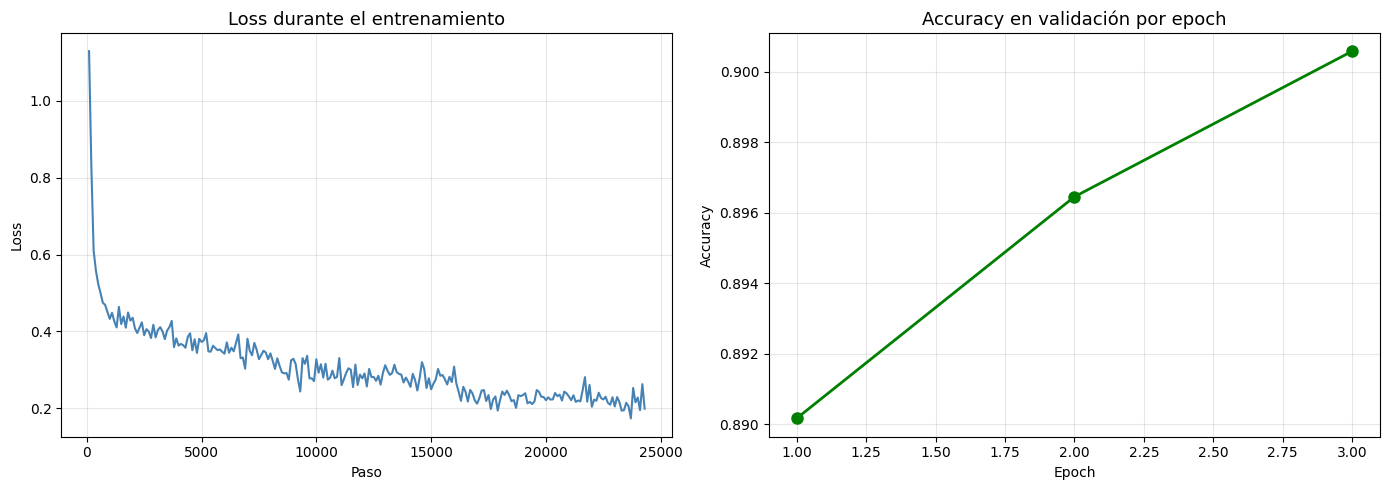

In [ ]:
# Extraemos el historial de entrenamiento
log_history = trainer.state.log_history

# Separamos los logs de entrenamiento y evaluación
train_losses = [(log['step'], log['loss']) for log in log_history if 'loss' in log and 'eval_loss' not in log]
eval_logs = [(log['epoch'], log['eval_loss'], log['eval_accuracy']) for log in log_history if 'eval_loss' in log]

# Gráfico 1: Loss durante el entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if train_losses:
    steps, losses = zip(*train_losses)
    axes[0].plot(steps, losses, color='steelblue', linewidth=1.5)
    axes[0].set_title('Loss durante el entrenamiento', fontsize=13)
    axes[0].set_xlabel('Paso')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

# Gráfico 2: Accuracy en validación por epoch
if eval_logs:
    epochs, eval_losses, eval_accs = zip(*eval_logs)
    axes[1].plot(epochs, eval_accs, 'o-', color='green', linewidth=2, markersize=8)
    axes[1].set_title('Accuracy en validación por epoch', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Qué nos dicen estos gráficos

**El loss** (izquierda) arrancó alto (1.15) y fue bajando hasta 0.20 durante las 3 epochss. La caída más fuerte fue al principio, después se fue estabilizando. Las oscilaciones son normales porque cada batch es distinto, pero la tendencia es clara: para abajo.

**El accuracy en validación** (derecha) fue subiendo de forma constante: 89.0% en la epoch 1, 89.6% en la 2 y 90.0% en la 3. A diferencia de la corrida anterior, acá no hubo sobreajuste, el modelo siguió mejorando en cada epoch.

---
## Guardar el modelo

Lo guardamos para poder usarlo después sin tener que volver a entrenar.

In [ ]:
# Guardamos el modelo y el tokenizador
RUTA_MODELO = "./modelo_quejas_financieras"
trainer.save_model(RUTA_MODELO)
tokenizer.save_pretrained(RUTA_MODELO)

print(f"Modelo guardado en: {RUTA_MODELO}")
print("\nPara cargar el modelo después:")
print(f'  model = AutoModelForSequenceClassification.from_pretrained("{RUTA_MODELO}")')
print(f'  tokenizer = AutoTokenizer.from_pretrained("{RUTA_MODELO}")')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en: ./modelo_quejas_financieras

Para cargar el modelo después:
  model = AutoModelForSequenceClassification.from_pretrained("./modelo_quejas_financieras")
  tokenizer = AutoTokenizer.from_pretrained("./modelo_quejas_financieras")


---
## Resumen de resultados

In [ ]:
print("=" * 60)
print("RESUMEN DEL PROYECTO")
print("=" * 60)
print(f"\nModelo utilizado: {NOMBRE_MODELO}")
print(f"Dataset: Consumer Complaints Dataset for NLP (Kaggle)")
print(f"Total de datos: {len(df)}")
print(f"Categorías: {num_categorias} ({', '.join(nombres_categorias)})")
print(f"\nHiperparámetros:")
print(f"  - Epoch: {training_args.num_train_epochs}")
print(f"  - Batch size: {training_args.per_device_train_batch_size}")
print(f"  - Learning rate: {training_args.learning_rate}")
print(f"  - Max length: {MAX_LENGTH}")
print(f"\nResultados en Test:")
print(f"  - Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"\nReporte detallado:")
print(report)
print("=" * 60)

RESUMEN DEL PROYECTO

Modelo utilizado: distilbert-base-uncased
Dataset: Consumer Complaints Dataset for NLP (Kaggle)
Total de datos: 162411
Categorías: 5 (credit_card, credit_reporting, debt_collection, mortgages_and_loans, retail_banking)

Hiperparámetros:
  - Epoch: 3
  - Batch size: 16
  - Learning rate: 2e-05
  - Max length: 256

Resultados en Test:
  - Accuracy: 0.8989 (89.89%)

Reporte detallado:
                     precision    recall  f1-score   support

        credit_card       0.83      0.82      0.82      1557
   credit_reporting       0.93      0.95      0.94      9118
    debt_collection       0.85      0.80      0.82      2315
mortgages_and_loans       0.88      0.83      0.85      1899
     retail_banking       0.89      0.90      0.89      1353

           accuracy                           0.90     16242
          macro avg       0.87      0.86      0.87     16242
       weighted avg       0.90      0.90      0.90     16242



---
## Resumen de lo que hicimos

1. **Cargamos y exploramos** el dataset de quejas de consumidores financieros (más de 162.000 registros). Vimos que hay un desbalance fuerte: credit_reporting tiene el 56% de los datos.
2. **Preprocesamos** todo: sacamos los valores vacíos, tokenizamos con DistilBERT y dividimos en train/val/test (80/10/10).
3. **Fine-tuneamos DistilBERT** para clasificar en 5 categorías. Usamos pesos de clase para que las categorías con menos datos (como retail_banking con 8%) no queden relegadas.
4. **Evaluamos** y obtuvimos 89.89% de accuracy y F1-score macro de 0.87. La mejor fue credit_reporting (F1: 0.94) y retail_banking (F1: 0.89) anduvo muy bien.
5. **Con las matrices de confusión** vimos que las principales confusiones pasan entre categorías que comparten vocabulario (debt_collection con credit_reporting: 14.00%).
6. **En los gráficos** se ve que el accuracy fue subiendo de forma constante en las 3 epochs (89.0% - 89.6% - 90.0%), sin señales de overfitting.

## Conclusiones

- DistilBERT con fine-tuning logró casi 90% de accuracy.
- Los pesos de clase funcionaron: retail_banking con apenas 8% de los datos llegó a F1 de 0.89.
- Las confusiones entre categorías tienen sentido porque comparten vocabulario (deudas, reportes, servicios bancarios).
- Con solo 256 tokens (que cubren el 94.6% de las quejas) alcanzó para tener buenos resultados.
- El loss bajó de 1.15 a 0.20 y el accuracy subió de forma constante, lo que indica un entrenamiento saludable.

### Posibles mejoras
- Probar con `bert-base-uncased` (más grande, capaz anda mejor)
- Subir `max_length` a 512 para no perder el 5.4% de quejas que se cortan
- Usar early stopping con más epochs para encontrar el punto justo
- Data augmentation para las clases chicas